# Convert Spike Train to Electrical Stimulus Sequence

In [1]:
%reload_ext autoreload
%autoreload 2

# Imports
import numpy as np
import visionloader as vl
import matplotlib.pyplot as plt
import os
import matplotlib.cm as cm
from tqdm import tqdm
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse
from scipy.io import loadmat
import scipy as sp

import sys
sys.path.append("/Volumes/Lab/Users/ajphillips/packages")
import eilib as eil

from quantities import ms, s, Hz
from elephant.spike_train_generation import homogeneous_poisson_process
from elephant.spike_train_dissimilarity import victor_purpura_distance
from neo.core import SpikeTrain

In [2]:
piece = '2024-09-25-3'
# analysis_base = f"/Volumes/Stream/Analysis/RETINA/{piece}"
analysis_base = f"/Volumes/Analysis/{piece}/RETINA"
label = ""

wnoise = "data003"
vstim = "data005_from_data003"
cell_types = ['ON parasol', 'OFF parasol']

dict_path = os.path.join(analysis_base, 'dictionary')
vstim_path = os.path.join(analysis_base, vstim)
wnoise_path = os.path.join(analysis_base, wnoise)

### Load electrical stimulus table

In [3]:
selective_stimuli = np.load(os.path.join(dict_path, f"selective_stimuli{label}.npz"))['selective_stimuli'] # selective_stimuli row is [electrode, cell, amp, pure]

### Determine spike trains of interest

In [4]:
wnoise_vcd = vl.load_vision_data(wnoise_path,wnoise,
                        include_neurons=True,
                        include_ei=True,
                        include_params=True,
                        include_runtimemovie_params=True)

coords = wnoise_vcd.get_electrode_map()

# coords_path = "/Volumes/Lab/Users/ajphillips/greedy/src/coords.npy"
# coords = np.load(coords_path)

In [5]:
vcd = vl.load_vision_data(vstim_path,vstim,
                        include_neurons=True)
                        # include_ei=True,
                        # include_params=True,
                        # include_runtimemovie_params=True)

In [6]:
# Get all cell IDs from cell types of interest
# cell_ids = []
# for cell_type in cell_types:
#     cell_ids.extend(vcd.get_all_cells_similar_to_type(cell_type))
# cell_ids = np.array(cell_ids)

# Get all selective cell IDs
cell_ids = np.unique(selective_stimuli[:,1])

spike_times = np.array([vcd.get_spike_times_for_cell(c) for c in cell_ids], dtype=object) / 20 # convert to ms

print(spike_times.shape)

(45,)


In [7]:
ttl_times = vcd.ttl_times / 20 # convert to ms
np.set_printoptions(suppress=True)
print(ttl_times)

[   534.6    2868.8    3036.1  ... 835179.65 835681.7  836183.6 ]


In [8]:
print(ttl_times[1525:1535])

[793217.5  793719.65 794221.6  794723.65 795225.35 796522.6  797024.45
 797526.5  798028.5  798530.7 ]


In [9]:
responses = []
for j in range(len(ttl_times)-1):
    if j == 1529: # CHANGE ME
        low = ttl_times[j]
        high = ttl_times[j] + 500
        filtered_spike_times = np.array([spike_time[(low < spike_time) & (spike_time < high)] for spike_time in spike_times], dtype=object)
        responses.append(filtered_spike_times)
    else:
        low = ttl_times[j]
        high = ttl_times[j+1]
        filtered_spike_times = np.array([spike_time[(low < spike_time) & (spike_time < high)] for spike_time in spike_times], dtype=object)
        responses.append(filtered_spike_times)
low = ttl_times[-1]
high = ttl_times[-1] + 500
filtered_spike_times = np.array([spike_time[(low < spike_time) & (spike_time < high)] for spike_time in spike_times], dtype=object)
responses.append(filtered_spike_times)

In [10]:
print(len(responses))

1610


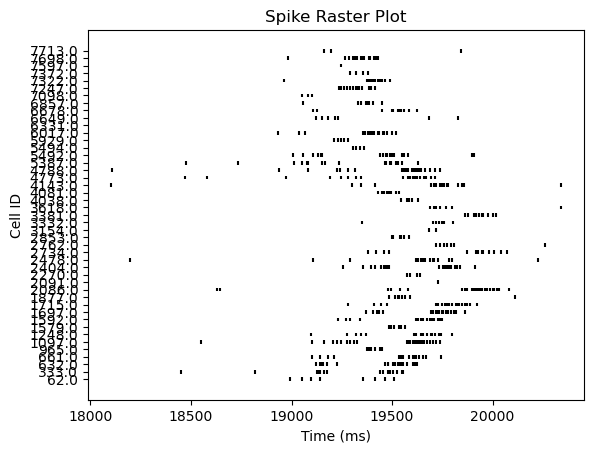

In [11]:
response = responses[14]
    
# Create a spike raster plot
plt.eventplot(response, linelengths=0.5, colors='black')

# Set the y-axis ticks and labels
plt.yticks(range(len(cell_ids)), cell_ids)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Spike Raster Plot')

# Show the plot
plt.show()

Response 0:


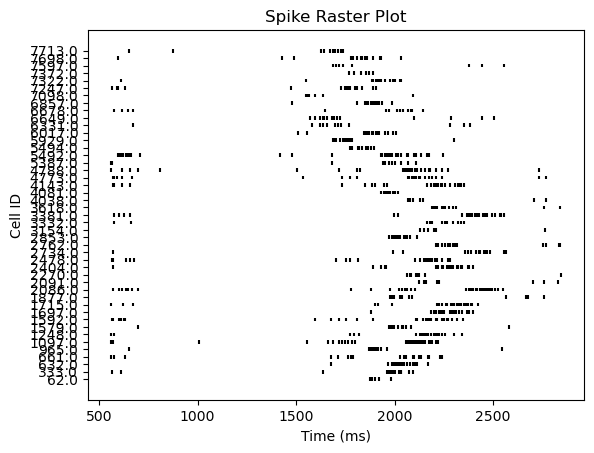

Response 2:


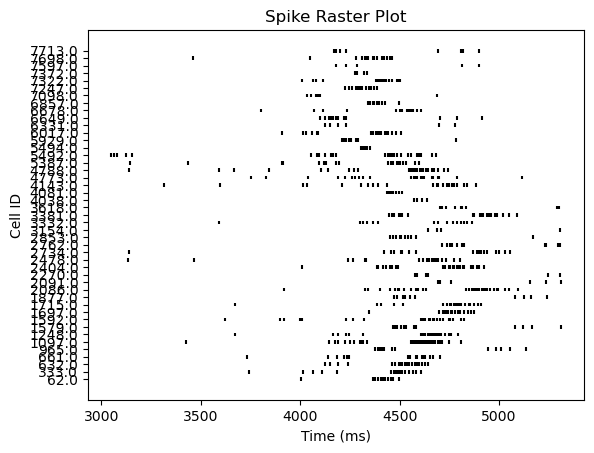

Response 4:


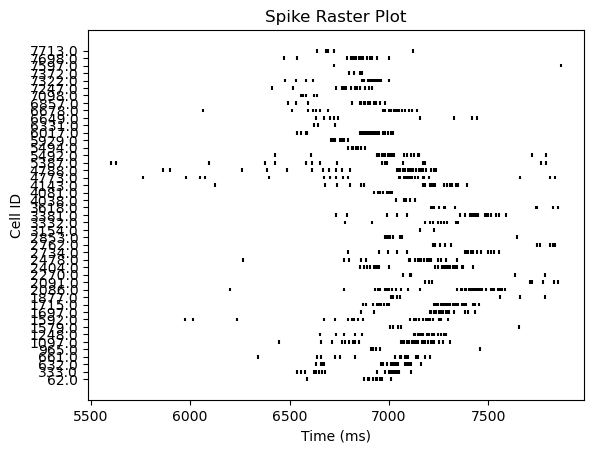

Response 6:


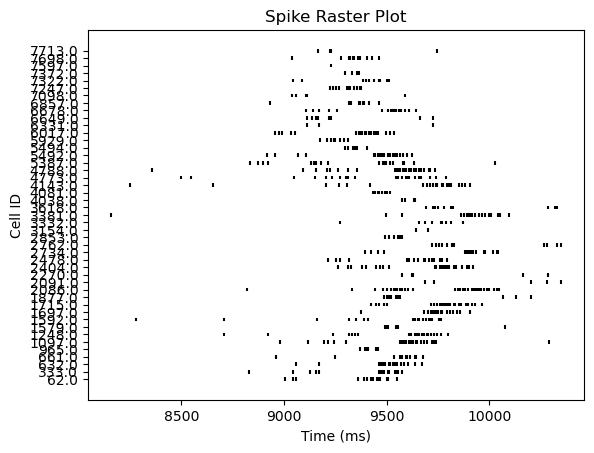

Response 8:


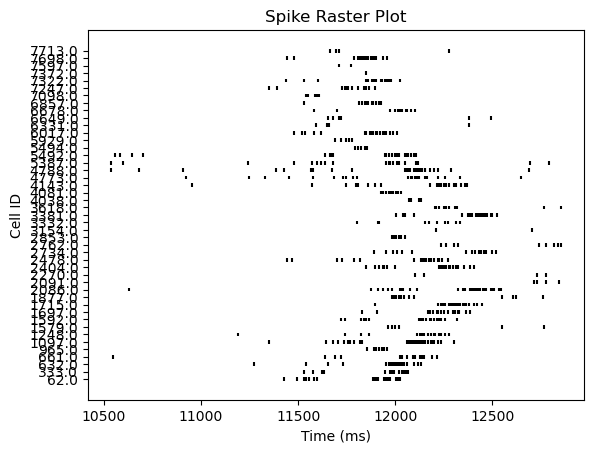

Response 10:


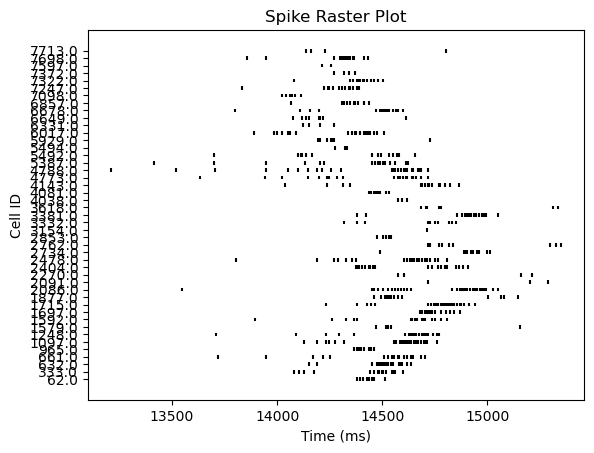

Response 12:


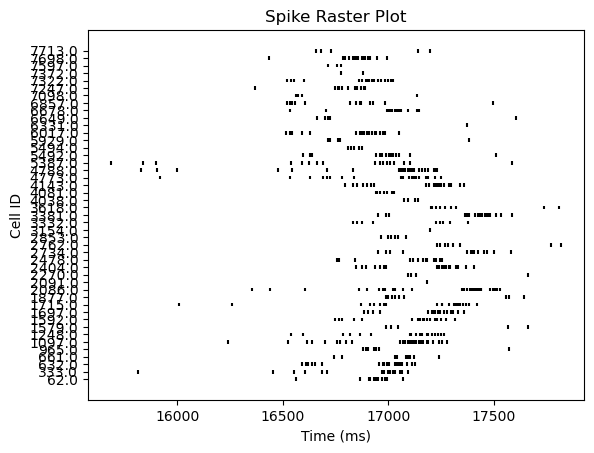

Response 14:


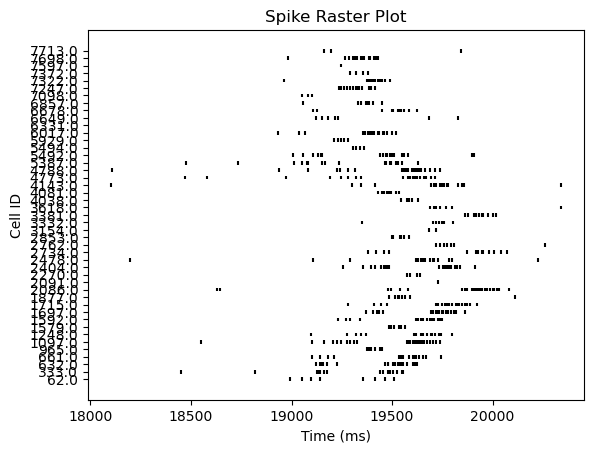

Response 16:


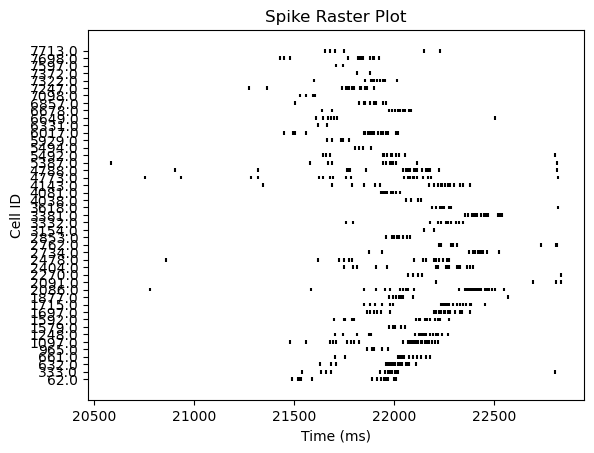

Response 18:


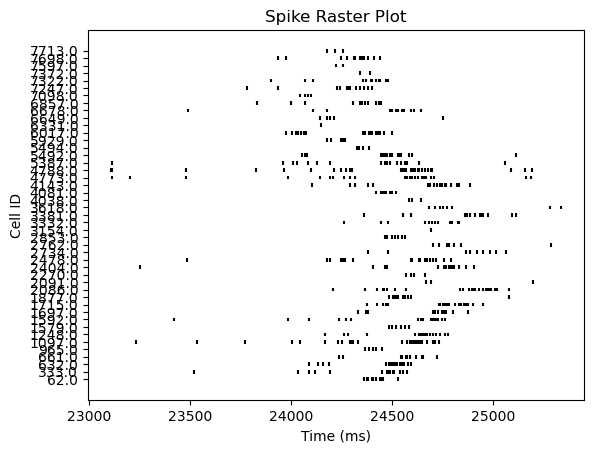

Response 20:


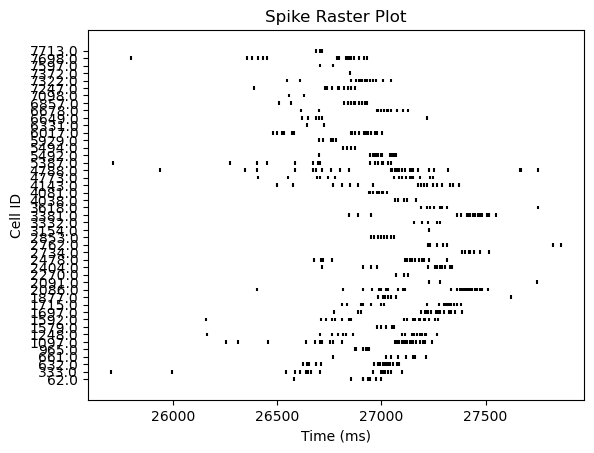

Response 22:


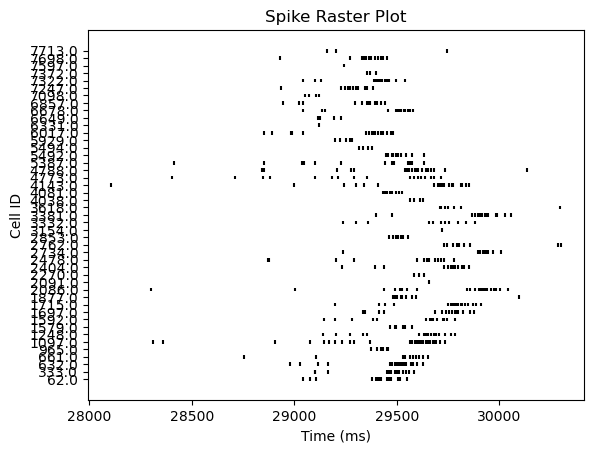

Response 24:


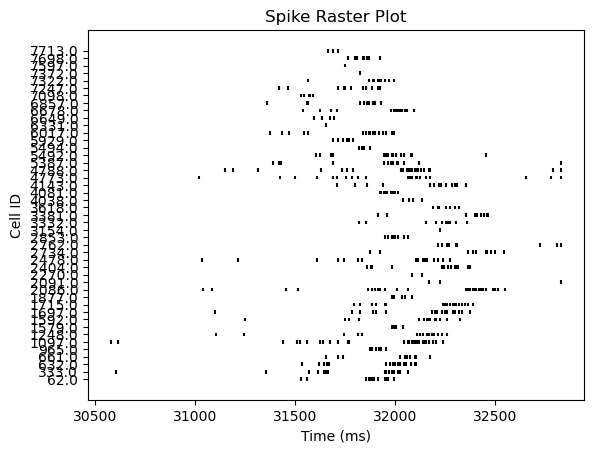

Response 26:


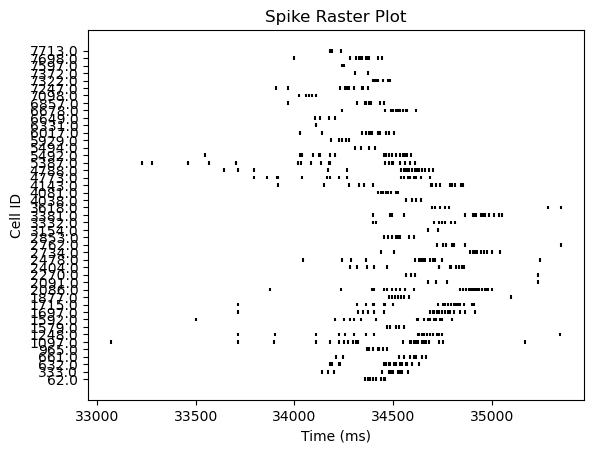

Response 28:


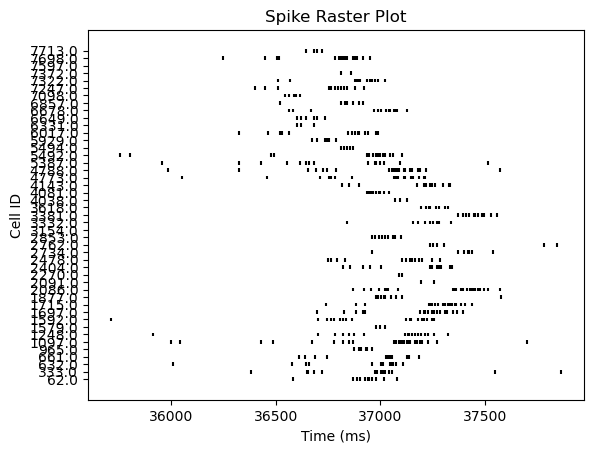

In [12]:
for i, response in enumerate(responses):
    if i > 29:
        break
    if i % 2 == 1:
        continue

    print(f"Response {i}:")
    
    # Create a spike raster plot
    plt.eventplot(response, linelengths=0.5, colors='black')

    # Set the y-axis ticks and labels
    plt.yticks(range(len(cell_ids)), cell_ids)
    plt.ylabel('Cell ID')

    # Set the x-axis label
    plt.xlabel('Time (ms)')

    # Set the plot title
    plt.title('Spike Raster Plot')

    # Show the plot
    plt.show()

In [13]:
response = responses[14]

# min_interspike_interval = np.array([np.min(np.diff(cell_spike_times)) for cell_spike_times in response])
min_interspike_interval = []
for i, cell_spike_times in enumerate(response):
    try:
        min_interspike_interval.append(np.min(np.diff(response[i])))
    except:
        continue
min_interspike_interval = np.array(min_interspike_interval)

average_interspike_interval = np.array([np.mean(np.diff(cell_spike_times)) for cell_spike_times in response])

proportions = []
for cell_spike_times in response:
    intervals = np.diff(cell_spike_times)
    proportion = np.mean(intervals < 2.5)
    proportions.append(proportion)
proportions = np.array(proportions)

print("Minimum Interspike Interval:")
print(min_interspike_interval)
print(np.mean(min_interspike_interval))

print("Average Interspike Interval:")
print(average_interspike_interval)
print(np.nanmean(average_interspike_interval))

print("Percentage of Interspike Intervals < 2.5 ms:")
print(proportions*100)
print(np.nanmean(proportions)*100)

Minimum Interspike Interval:
[42.1   3.4   3.4   4.    9.8   5.1   5.65  9.15  5.8   7.6   5.8   6.45
  4.9  13.25  7.65  4.95  4.35 11.2   7.9  35.75 11.15  3.45 13.65 10.15
  4.6   5.75  6.1   5.    5.7   4.4  13.5  15.25  3.95 12.6   6.95  7.1
 19.4   7.7   4.   25.7   5.05 33.45]
10.066666666666736
Average Interspike Interval:
[ 73.60714286  73.66333333  26.52631579  43.03333333  14.71
  47.514       43.934375    15.66        36.82142857  29.02352941
  35.80833333  89.89285714  60.32291667          nan  21.46666667
  36.67222222 135.50666667  53.33076923  90.275       17.09
  35.75        75.05833333  15.225      108.68333333  21.375
  12.81875    149.44666667  68.9         77.84047619  71.959375
  52.82058824  18.71666667  18.35        36.46875             nan
 117.825       52.035       55.72857143  25.575       14.83333333
  48.03636364  29.96666667          nan  34.31153846 339.75      ]
57.769840551854834
Percentage of Interspike Intervals < 2.5 ms:
[ 0.  0.  0.  0.  0.  0.  0

/Volumes/Lab/Development/anaconda3/envs/RETINA/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Volumes/Lab/Development/anaconda3/envs/RETINA/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [14]:
bin_size_ms = 2.5
rounded_response = np.array([np.round(cell_spike_times / bin_size_ms) * bin_size_ms for cell_spike_times in response], dtype=object)

print(rounded_response.shape)

(45,)


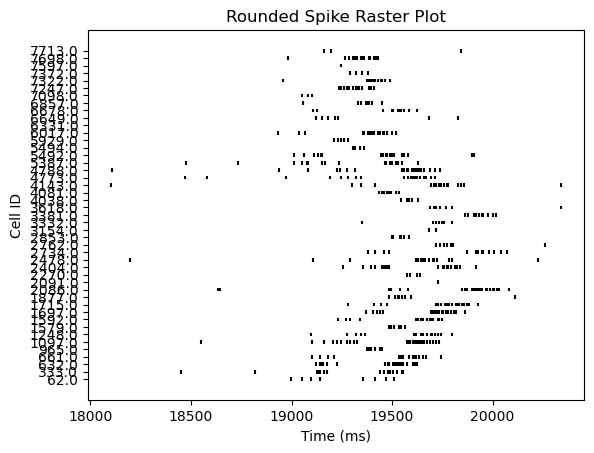

In [15]:
# Create a spike raster plot
plt.eventplot(rounded_response, linelengths=0.5, colors='black')

# Set the y-axis ticks and labels
plt.yticks(range(len(cell_ids)), cell_ids)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Rounded Spike Raster Plot')

# Show the plot
plt.show()

In [16]:
print(rounded_response)

[array([18995. , 19050. , 19097.5, 19142.5, 19357.5, 19415. , 19467.5,
        19510. ])
 array([18450. , 18817.5, 19127.5, 19137.5, 19140. , 19160. , 19177.5,
        19440. , 19457.5, 19480. , 19482.5, 19490. , 19502.5, 19525. ,
        19547.5, 19555. ])
 array([19122.5, 19140. , 19147.5, 19155. , 19177.5, 19225. , 19465. ,
        19477.5, 19482.5, 19502.5, 19507.5, 19517.5, 19530. , 19537.5,
        19545. , 19552.5, 19572.5, 19605. , 19615. , 19625. ])
 array([19100. , 19140. , 19182.5, 19210. , 19535. , 19540. , 19547.5,
        19552.5, 19585. , 19602.5, 19610. , 19617.5, 19632.5, 19652.5,
        19670. , 19745. ])
 array([19377.5, 19387.5, 19397.5, 19415. , 19437.5, 19450. ])
 array([18547.5, 19102.5, 19162.5, 19207.5, 19227.5, 19247.5, 19275. ,
        19290. , 19312.5, 19325. , 19575. , 19582.5, 19590. , 19602.5,
        19615. , 19622.5, 19630. , 19637.5, 19645. , 19652.5, 19657.5,
        19672.5, 19690. , 19702.5, 19717.5, 19735. ])
 array([19095. , 19277.5, 19322.5, 193

In [17]:
from collections import Counter

def assign_stimuli_to_responses(response, cell_ids, selective_stimuli, plot=False):
    # responses is a list of arrays of spike times for each cell
    # cell_ids is an array of cell IDs
    # selective_stimuli is an array of selective stimuli

    concat_response = np.concatenate(response)

    # max_n = Counter(concat_response).most_common(1)[0][1]
    # print(f"Maximum number of simultaneous cells firing: {max_n}")

    concat_spike_times = np.unique(concat_response)
    print(f"Unique stimulus times: {concat_spike_times.size}")

    if concat_spike_times.size == 0:
        return np.array([[0, 2, 0.09375]])

    sef = np.empty((0,3))
    crowded_count = 0

    for t in concat_spike_times:
        print("-------------------")
        print(f"Stimulus time: {t} ms")
        # Determine which of the response arrays contain the stimulus time
        response_indices = [i for i, cell_spike_times in enumerate(response) if t in cell_spike_times]
        cell_ids_for_stimulus = cell_ids[response_indices]
        print(f"Cell IDs: {cell_ids_for_stimulus}")
        # Report and remove any cell IDs that are not in the selective stimuli
        if len([cell_id for cell_id in cell_ids_for_stimulus if cell_id not in selective_stimuli[:,1]]) > 0:
            print(f"Can't selectively stimulate cell IDs: {[cell_id for cell_id in cell_ids_for_stimulus if cell_id not in selective_stimuli[:,1]]}")
        cell_ids_for_stimulus = np.array([cell_id for cell_id in cell_ids_for_stimulus if cell_id in selective_stimuli[:,1]])

        # Continue if there are no cell IDs to stimulate
        if cell_ids_for_stimulus.size == 0:
            print("Skipping stimulus time...")
            continue

        # sef = np.vstack((sef, assign_stimuli(t, cell_ids_for_stimulus, selective_stimuli, plot))) # IMPORTANT SMART OR NOT CHANGE
        sef_row, crowded = assign_stimuli_smart(t, cell_ids_for_stimulus, selective_stimuli, plot)
        sef = np.vstack((sef, sef_row))
        if crowded:
            crowded_count += 1

    print("-------------------")
    print(f"{crowded_count / len(concat_spike_times) * 100:.1f}% crowded stimuli")

    return sef


def assign_stimuli(t, cell_ids_for_stimulus, selective_stimuli, plot):
    # selective_stimuli row is [electrode, cell, amp, pure]
    # sef row is [time, electrode, amp]

    # Find the selective stimuli that match the cell IDs
    matching_stimuli = []
    for cell_id in cell_ids_for_stimulus:
        matching_stimuli.extend([stimulus for stimulus in selective_stimuli if stimulus[1] == cell_id])
    matching_stimuli = np.array(matching_stimuli)

    if len(cell_ids_for_stimulus) == 1:
        print(f"Selected electrodes: {matching_stimuli[0,0].astype(int)}")
        return [t, matching_stimuli[0,0], matching_stimuli[0,2]]

    # Find the convex hull of the electrodes in the matching stimuli on the electrode array
    electrodes = np.array([stimulus[0] for stimulus in matching_stimuli])
    electrodes = electrodes.astype(int)

    if len(electrodes) == 2:
        print(f"Selected electrodes: {electrodes.astype(int)}")
        return np.array([[t, matching_stimuli[0,0], matching_stimuli[0,2]], 
                        [t, matching_stimuli[1,0], matching_stimuli[1,2]]])

    # Plot the electrodes
    if plot:
        fig, ax = plt.subplots()
        ax.plot(coords[:,0], coords[:,1], 'k.')

        # Plot the selective electrodes corresponding to each cell_id in different colors
        colors = cm.rainbow(np.linspace(0, 1, len(cell_ids_for_stimulus)))
        for i, cell_id in enumerate(cell_ids_for_stimulus):
            cell_id_elecs = matching_stimuli[np.where(matching_stimuli[:,1] == cell_id)[0]][:,0].astype(int)
            ax.plot(coords[cell_id_elecs-1,0], coords[cell_id_elecs-1,1], 'o', color=colors[i])

    # For the first two cells, find an electrode for each of the cells that activates the cell and is farthest away from the other found electrode
    selected_electrodes = []
    cell_id_elecs0 = matching_stimuli[np.where(matching_stimuli[:,1] == cell_ids_for_stimulus[0])[0]][:,0].astype(int)
    cell_id_elecs1 = matching_stimuli[np.where(matching_stimuli[:,1] == cell_ids_for_stimulus[1])[0]][:,0].astype(int)
    distances = sp.spatial.distance.cdist(coords[cell_id_elecs0-1], coords[cell_id_elecs1-1])
    index = np.unravel_index(np.argmax(distances), distances.shape)
    selected_electrode = cell_id_elecs0[index[0]]
    selected_electrodes.append(selected_electrode)
    # Designate these electrodes on the plot
    if plot:
        ax.plot(coords[selected_electrode-1,0], coords[selected_electrode-1,1], 'X', color=colors[0], markersize=15)
    selected_electrode = cell_id_elecs1[index[1]]
    selected_electrodes.append(selected_electrode)
    # Designate these electrodes on the plot
    if plot:
        ax.plot(coords[selected_electrode-1,0], coords[selected_electrode-1,1], 'X', color=colors[1], markersize=15)


    # Find an electrode for each of the remaining cell IDs that activates the cell and is farthest away from all other found electrodes
    for i, cell_id in enumerate(cell_ids_for_stimulus):
        if i < 2:
            continue
        cell_id_elecs = matching_stimuli[np.where(matching_stimuli[:,1] == cell_id)[0]][:,0].astype(int)
        distances = sp.spatial.distance.cdist(coords[cell_id_elecs-1], coords[np.array(selected_electrodes)-1])
        index = np.argmax(np.sum(distances, axis=1))
        selected_electrode = cell_id_elecs[index]
        selected_electrodes.append(selected_electrode)
        # Designate these electrodes on the plot
        if plot:
            ax.plot(coords[selected_electrode-1,0], coords[selected_electrode-1,1], 'X', color=colors[i], markersize=15)

    if plot:
        ax.set_aspect('equal')
        plt.show()

    print(f"Selected electrodes: {selected_electrodes}")

    to_return = np.empty((0,3))
    for i, cell_id in enumerate(cell_ids_for_stimulus):
        to_return = np.vstack((to_return, [t, selected_electrodes[i], matching_stimuli[np.where(matching_stimuli[:,0:1] == [selected_electrodes[i], cell_id])[0][0],2]]))
    return to_return


def assign_stimuli_smart(t, cell_ids_for_stimulus, selective_stimuli, plot):
    # selective_stimuli row is [electrode, cell, amp, pure]
    # sef row is [time, electrode, amp]

    # Find the selective stimuli that match the cell IDs
    matching_stimuli = []
    for cell_id in cell_ids_for_stimulus:
        matching_stimuli.extend([stimulus for stimulus in selective_stimuli if stimulus[1] == cell_id])
    matching_stimuli = np.array(matching_stimuli)

    # Plot the electrodes
    if plot:
        fig, ax = plt.subplots()
        ax.scatter(coords[:,0], coords[:,1], s=1, c='k')

        # Plot the selective electrodes corresponding to each cell_id in different colors
        colors = cm.rainbow(np.linspace(0, 1, len(cell_ids_for_stimulus)))
        for i, cell_id in enumerate(cell_ids_for_stimulus):
            cell_id_elecs = matching_stimuli[np.where(matching_stimuli[:,1] == cell_id)[0]][:,0].astype(int)
            # ax.scatter(coords[cell_id_elecs-1,0], coords[cell_id_elecs-1,1], s=15, color=colors[i])

    # Choose the selective electrode closest to the soma center for each cell
    selected_electrodes = []
    for i, cell_id in enumerate(cell_ids_for_stimulus):
        cell_ei = wnoise_vcd.get_ei_for_cell(cell_id).ei
        ei = np.amin(cell_ei,axis=1)

        # Find soma position
        thresh = -2
        inds = np.argwhere(ei < thresh).flatten()
        soma_inds = []
        soma_ei_vals = []
        for ind in inds:
            if eil.axonorsomaRatio(cell_ei[ind,:]) == 'soma':
                soma_inds.append(ind)
                soma_ei_vals.append(np.min(cell_ei[ind,:]))
        soma_pos = eil.getSomaLocThr(np.array(soma_inds), np.array(soma_ei_vals), coords)

        # Find the selective electrode closest to the soma center
        cell_id_matching_stimuli = matching_stimuli[np.where(matching_stimuli[:,1] == cell_id)[0]]
        index = np.argmin(np.linalg.norm(coords[cell_id_matching_stimuli[:,0].astype(int)-1] - soma_pos, axis=1))
        selected_electrode = cell_id_matching_stimuli[index][0].astype(int)
        selected_electrodes.append(selected_electrode)
        # Designate these electrodes on the plot
        if plot:
            ax.scatter(coords[selected_electrode-1,0], coords[selected_electrode-1,1], s=150, color=colors[i], marker='X')
            # ons = [965, 1579, 1877, 2091, 2270, 2762, 2853, 3154, 3618, 4038, 4081, 5494, 5929, 6331, 6649, 7098, 7372, 7597, 7713]
            # offs = [62, 333, 632, 661, 1097, 1248, 1592, 1697, 1715, 2086, 2404, 2478, 2734, 3332, 3381, 4143, 4773, 4788, 5387, 5492, 6017, 6678, 6857, 7247, 7322, 7698]
            # marker_size = matching_stimuli[np.where(matching_stimuli[:,0:1] == [selected_electrode, cell_id])[0][0],2] / 3.9375 * 750
            # if cell_id in ons:
            #     ax.scatter(coords[selected_electrode-1,0], coords[selected_electrode-1,1], s=marker_size, color='blue', marker='.')
            # elif cell_id in offs:
            #     ax.scatter(coords[selected_electrode-1,0], coords[selected_electrode-1,1], s=marker_size, color='red', marker='.')
            # else:
            #     raise ValueError(f"Cell ID {cell_id} not found in ON or OFF parasol list")


    if plot:
        ax.set_aspect('equal')
        # ax.set_frame_on(False)
        # ax.axes.get_xaxis().set_visible(False)
        # ax.axes.get_yaxis().set_visible(False)
        # ax.invert_yaxis()
        plt.show()

    print(f"Selected electrodes: {selected_electrodes}")

    # Print warning if any of the selected electrodes are closer than 200 microns
    crowded = False
    distances = sp.spatial.distance.cdist(coords[np.array(selected_electrodes)-1], coords[np.array(selected_electrodes)-1])
    np.fill_diagonal(distances, np.inf)
    if np.min(distances) < 200:
        print(f"WARNING: Selected electrodes are minimum {np.min(distances):.0f} microns apart")
        crowded = True

    to_return = np.empty((0,3))
    for i, cell_id in enumerate(cell_ids_for_stimulus):
        to_return = np.vstack((to_return, [t, selected_electrodes[i], matching_stimuli[np.where(matching_stimuli[:,0:1] == [selected_electrodes[i], cell_id])[0][0],2]]))
    return to_return, crowded


def convert_sef_to_board(sef):
    amplitudes = np.array([0.09375, 0.1875, 0.28125, 0.375, 0.46875, 0.5625, 0.65625, 0.75, 0.84375, 0.9375,
            1.03125, 1.125, 1.21875, 1.3125, 1.40625, 1.5, 1.59375, 1.6875, 1.78125, 1.875, 1.96875,
            2.0625, 2.15625, 2.25, 2.34375, 2.4375, 2.53125, 2.625, 2.71875, 2.8125, 2.90625, 3.0,
            3.09375, 3.1875, 3.28125, 3.375, 3.46875, 3.5625, 3.65625, 3.75, 3.84375, 3.9375])

    # Subtract time 0 from all times
    board_sef = sef.copy()
    board_sef[:,0] -= board_sef[0,0]
    board_sef[:,0] *= 20

    # Avoid multiples of the stimulation window boundary
    board_sef[:,0] += 1

    # Find the index of the closest amplitude to the amplitude in the sef
    for i in range(board_sef.shape[0]):
        board_sef[i,2] = np.argmin(np.abs(amplitudes - board_sef[i,2])) + 1 # 1-indexed

    board_sef = board_sef.astype(int)
    return board_sef

def map_electrodes_to_channels_519(electrodes):

    # newLVChan2Elec519 is (512,) containing channel (1-index) to electrode (value) mapping
    mat_data = loadmat('/Volumes/Lab/Users/AlexG/pystim/files/adj-elecs-tools/newLVChan2Elec519.mat')
    newLVChan2Elec519 = np.squeeze(mat_data['channel2Elec519'])

    # Throw an error if any electrode number is not valid
    if not np.all(np.isin(electrodes, newLVChan2Elec519)):
        raise ValueError(f"Invalid electrode number in {electrodes}")

    channels = []
    for electrode in electrodes:
        channels.append(np.where(newLVChan2Elec519 == electrode)[0][0] + 1)
    return np.array(channels)

def map_channels_to_electrodes_519(channels):

    # newLVChan2Elec519 is (512,) containing channel (1-index) to electrode (value) mapping
    mat_data = loadmat('/Volumes/Lab/Users/AlexG/pystim/files/adj-elecs-tools/newLVChan2Elec519.mat')
    newLVChan2Elec519 = np.squeeze(mat_data['channel2Elec519'])
    
    # Throw an error if any channel number is not valid
    if not np.all(np.isin(channels, np.arange(1, 513))):
        raise ValueError(f"Invalid channel number in {channels}")
    
    electrodes = []
    for channel in channels:
        electrodes.append(newLVChan2Elec519[channel-1])
    return np.array(electrodes)

In [ ]:
sef = convert_sef_to_board(assign_stimuli_to_responses(rounded_response,cell_ids,selective_stimuli,plot=True))

### Central response: normalized VP distance 

In [ ]:
# print(np.max(np.diff(ttl_times[30:])))

In [ ]:
# def get_central_response(response_indices, q):

#     spike_trains = np.empty((len(response_indices), len(cell_ids)), dtype=object) # (num_trials, num_cells)
#     for i,ri in enumerate(response_indices):
#         response = responses[ri] - ttl_times[ri] # subtract off the start time of the jittered natural scene
#         for j in range(len(response)):
#             spike_trains[i,j] = SpikeTrain(response[j]*ms, t_start=0.0*ms, t_stop=1305.0*ms)

#     vp_distance = np.empty((spike_trains.shape[1], spike_trains.shape[0], spike_trains.shape[0]))
#     for i in tqdm(range(spike_trains.shape[1])):

#         spike_train_list = []
#         for j in range(spike_trains.shape[0]):
#             spike_train_list.append(spike_trains[j,i])

#         # Get the number of spikes in each spike train
#         num_spikes = np.array([len(spike_train.times) for spike_train in spike_train_list])

#         # Build a normalization matrix where each entry is the sum of the number of spikes in the two spike trains corresponding to the indices of that entry
#         normalization_matrix = np.zeros((len(spike_train_list), len(spike_train_list)))
#         for j in range(len(spike_train_list)):
#             for k in range(len(spike_train_list)):
#                 normalization_matrix[j,k] = num_spikes[j] + num_spikes[k]

#         normalized_vp = victor_purpura_distance(spike_train_list, cost_factor=q) / normalization_matrix # Normalize the distance by the sum of the spikes in the compared spike trains
#         normalized_vp[np.isnan(normalized_vp)] = 0 # If both spike trains are empty, define normalized distance as 0
#         vp_distance[i] = normalized_vp

#     # Find the trial with the minimum average distance to all other trials
#     multi_vp_distance = np.sum(vp_distance, axis=0)
#     central_response_index = np.argmin(np.sum(multi_vp_distance, axis=1))
    
#     return response_indices[central_response_index]


In [ ]:
# response_indices = np.arange(30,130)
# print(response_indices)

# q = 1. / (5. * ms)

In [ ]:
# central_response_indices = []
# for ri in response_indices:
#     all_trials = np.arange(ri, 1530, 100) # UPDATE ME DEPENDING ON STRUCTURE OF TTL_TIMES
#     central_response_indices.append(get_central_response(all_trials, q))
# central_response_indices = np.array(central_response_indices)
# print(central_response_indices)

In [ ]:
# from multiprocessing import Pool

# def get_central_response_star(args):
#     return get_central_response(*args)

# args = []
# for ri in response_indices:
#     all_trials = np.arange(ri, 1530, 100) # UPDATE ME DEPENDING ON STRUCTURE OF TTL_TIMES
#     args.append((all_trials,q))

# rolling_e = np.array([3, 2, 3, 2, 1, 1, 2, 0, 3, 2, 2, 0, 0, 3, 1, 3, 0, 1, 1, 3, 0, 0, 1, 1, 3, 0, 1, 1, 0, 1, 3, 0, 1, 3, 2, 3, 0, 2, 1, 2, 2, 3, 2, 0, 3, 1, 3, 1, 3, 1, 3, 3, 2, 3, 0, 0, 1, 0, 0, 2, 1, 0, 1, 2, 3, 3, 1, 3, 0, 2, 0, 2, 2, 2, 2, 2, 1, 0, 2, 0])
# for i in range(4):
#     all_trials = np.where(rolling_e == i)[0] + 1530
#     args.append((all_trials,q))

# with Pool(processes=40) as p:
#     central_response_indices = p.map(get_central_response_star, args)

# central_response_indices = np.array(central_response_indices)
# print(central_response_indices)

In [ ]:
# ri = 120
# all_trials = np.arange(ri, 1530, 100)
# central_response_index = get_central_response(all_trials, q)
# print(f"Central response index: {central_response_index}")

# for t in all_trials:

#     print(f"Response {t}:")
    
#     # Create a spike raster plot
#     if t == central_response_index:
#         plt.eventplot(responses[t], linelengths=0.5, colors='red')
#     else:
#         plt.eventplot(responses[t], linelengths=0.5, colors='black')

#     # Set the y-axis ticks and labels
#     plt.yticks(range(len(cell_ids)), cell_ids)
#     plt.ylabel('Cell ID')

#     # Set the x-axis label
#     plt.xlabel('Time (ms)')

#     # Set the plot title
#     plt.title('Spike Raster Plot')

#     # Show the plot
#     plt.show()

### Central response: median total spikes

In [18]:
def get_median_response(response_indices):

    # Get response index with the median number of spikes
    total_spikes = np.empty((len(response_indices), len(cell_ids)))
    for i,ri in enumerate(response_indices):
        response = responses[ri] - ttl_times[ri] # subtract off the start time of the jittered natural scene
        for j in range(len(response)):
            total_spikes[i,j] = len(response[j])

    median_response_index = np.argsort(np.sum(total_spikes, axis=1))[total_spikes.shape[0]//2]

    return response_indices[median_response_index]

Specify the response index of the first trial of the visual stimuli you want to reproduce...

In [ ]:
ri = 30
all_trials = np.arange(ri, 1530, 100)
median_response_index = get_median_response(all_trials)
print(f"Median response index: {median_response_index}")

for t in all_trials:

    print(f"Response {t}:")
    
    # Create a spike raster plot
    if t == median_response_index:
        plt.eventplot(responses[t], linelengths=0.5, colors='red')
    else:
        plt.eventplot(responses[t], linelengths=0.5, colors='black')

    # Set the y-axis ticks and labels
    plt.yticks(range(len(cell_ids)), cell_ids)
    plt.ylabel('Cell ID')

    # Set the x-axis label
    plt.xlabel('Time (ms)')

    # Set the plot title
    plt.title('Spike Raster Plot')

    # Show the plot
    plt.show()

In [21]:
response_indices = np.arange(30,130)
print(response_indices)

[ 30  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47
  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65
  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83
  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119
 120 121 122 123 124 125 126 127 128 129]


In [35]:
from multiprocessing import Pool

args = []

args.append(np.arange(0,30,2))

for ri in response_indices:
    all_trials = np.arange(ri, 1530, 100) # UPDATE ME DEPENDING ON STRUCTURE OF TTL_TIMES
    args.append(all_trials)

rolling_e = np.array([3, 2, 3, 2, 1, 1, 2, 0, 3, 2, 2, 0, 0, 3, 1, 3, 0, 1, 1, 3, 0, 0, 1, 1, 3, 0, 1, 1, 0, 1, 3, 0, 1, 3, 2, 3, 0, 2, 1, 2, 2, 3, 2, 0, 3, 1, 3, 1, 3, 1, 3, 3, 2, 3, 0, 0, 1, 0, 0, 2, 1, 0, 1, 2, 3, 3, 1, 3, 0, 2, 0, 2, 2, 2, 2, 2, 1, 0, 2, 0])
for i in range(4):
    all_trials = np.where(rolling_e == i)[0] + 1530
    args.append(all_trials)

with Pool(processes=40) as p:
    median_response_indices = p.map(get_median_response, args)

median_response_indices = np.array(median_response_indices)
print(median_response_indices)

[  14  730 1231  932  633  534 1335  836 1037  638   39 1040  741  342
  843  144  145  646 1147  248  449  550  451  852  253  454  655  956
  257 1158   59  560  661 1162   63  164 1065  966  867 1068 1269 1070
  971  172  873 1174  775   76  177  678 1479  880  281  882  983  884
  585  386 1387  588  489  690 1091  292  393 1094  795 1196  797  298
  699  800  901  902  803 1104  405  306  807 1308  709  910  611  812
  813  814  715  816  817  618  119 1320 1521  822  923  824  925  526
  727 1128 1329 1609 1568 1569 1543]


In [ ]:
print(median_response_indices)
print(len(median_response_indices))

all_sef_arrays = []
for ri in median_response_indices:
    response = responses[ri]
    rounded_response = np.array([np.round(cell_spike_times / bin_size_ms) * bin_size_ms for cell_spike_times in response], dtype=object)
    sef = convert_sef_to_board(assign_stimuli_to_responses(rounded_response,cell_ids,selective_stimuli,plot=False))
    sef[:,1] = map_electrodes_to_channels_519(sef[:,1])
    all_sef_arrays.append(sef)

print(len(all_sef_arrays))

[  10  530  631  832 1133  834  735  436 1037  638 1439 1340  741 1242
 1343  644  845  646  647  748 1349  650 1351 1052  553  654 1455  656
 1157 1458 1159 1360 1461 1362  763  964  765 1366 1367  868 1369 1270
  771  972 1473  874  775 1376  777  578  979  880  681  782  683 1484
 1285 1286  687 1388  589  690  591  692 1293  994  995 1396 1297 1498
 1399  700 1301  902  703 1404  705 1206  707 1308  509 1410  711 1412
  713  914 1515  616 1417 1118  919  820  721 1222  723  624  925 1226
 1427  628  929 1584 1552 1599 1576]
105
Unique stimulus times: 306
-------------------
Stimulus time: 13035.0
Cell IDs: [5506.]
Selected electrodes: [73]
-------------------
Stimulus time: 13040.0
Cell IDs: [5506.]
Selected electrodes: [73]
-------------------
Stimulus time: 13052.5
Cell IDs: [46.]
Selected electrodes: [9]
-------------------
Stimulus time: 13055.0
Cell IDs: [46.]
Selected electrodes: [9]
-------------------
Stimulus time: 13075.0
Cell IDs: [2131.]
Selected electrodes: [287]
-----

In [28]:
num_repeats = 15
all_sef_arrays_repeat = [sef.astype(np.int32) for sef in all_sef_arrays for _ in range(num_repeats)]

In [29]:
# Add 300 to the first SEF sequence to give adequate time for the initial current range setting [1 0 -4]
all_sef_arrays_repeat[0][:,0] += 300
all_sef_arrays_repeat = np.array(all_sef_arrays_repeat, dtype=object)

save_path = os.path.join(dict_path, f"spike_trains{label}.npz")
np.savez(save_path, sef=all_sef_arrays_repeat, response_indices=median_response_indices, allow_pickle=True)